In [17]:
import os
import sys
import pickle
import numpy as np
import pandas as pd

# allow importing the "backbone" package when the kernel's cwd is noteonooks/
sys.path.append(os.path.abspath(".."))

import backbone.custom_metrics.AstroMLmod3 as AstroMLmod
import backbone.custom_metrics.Intrinsic_dimension as id_module
from backbone.data_handle.Test import KNN_accuracy
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import davies_bouldin_score

# Test representations: TPCF & ID scores per epoch

In [18]:
n_epochs = 100

tpcf_scores = []
tpcf_std_scores = []
id_scores = []
cosine_sim_scores = []
cosine_sim_std_scores = []
anisotropy_scores = []
davies_bouldin_scores = []
knn_accuracy_scores = []
knn_accuracy_std_scores = []

for epoch in range(n_epochs):
    pkl_filename = f"../Plots/Test_representations_labels{epoch}.csv"
    with open(pkl_filename, 'rb') as file:
        test_rep = pickle.load(file)

    representations = np.array(test_rep[0])
    labels = test_rep[1]
    n = representations.shape[0]

    # TPCF_score bootstraps over subsamples and returns (mean, std)
    tpcf, tpcf_std = AstroMLmod.TPCF_score(representations, epoch=epoch)
    id_ = id_module.id_score(representations)
    db_score = davies_bouldin_score(representations, labels)
    knn_acc, knn_acc_std = KNN_accuracy(representations, labels)

    # average pairwise cosine similarity, excluding self-similarity on the diagonal
    cos_sim_matrix = cosine_similarity(representations)
    off_diag_mask = ~np.eye(n, dtype=bool)
    avg_cos_sim = cos_sim_matrix[off_diag_mask].mean()
    std_cos_sim = cos_sim_matrix[off_diag_mask].std()

    # anisotropy: fraction of variance explained by the top singular direction
    centered = representations - representations.mean(axis=0, keepdims=True)
    singular_values = np.linalg.svd(centered, compute_uv=False)
    explained_variance = (singular_values ** 2) / (n - 1)
    explained_variance_ratio = explained_variance / explained_variance.sum()
    anisotropy = explained_variance_ratio[0]

    tpcf_scores.append(tpcf)
    tpcf_std_scores.append(tpcf_std)
    id_scores.append(id_)
    cosine_sim_scores.append(avg_cos_sim)
    cosine_sim_std_scores.append(std_cos_sim)
    anisotropy_scores.append(anisotropy)
    davies_bouldin_scores.append(db_score)
    knn_accuracy_scores.append(knn_acc)
    knn_accuracy_std_scores.append(knn_acc_std)

    print(f"Epoch {epoch}: TPCF={tpcf:.4f}±{tpcf_std:.4f} ID={id_} CosineSim={avg_cos_sim:.4f}±{std_cos_sim:.4f} Anisotropy={anisotropy:.4f} DaviesBouldin={db_score:.4f} KNNAcc={knn_acc:.2f}±{knn_acc_std:.2f}")


Epoch 0: TPCF=568.2100±330.3700 ID=(np.float64(52.743260870074586), np.float64(1.6315948275090064)) CosineSim=0.1953±0.1200 Anisotropy=0.9690 DaviesBouldin=12.2427 KNNAcc=20.16±0.43
Epoch 1: TPCF=6038.6600±1038.9900 ID=(np.float64(6.493028307663323), np.float64(0.25217636138031363)) CosineSim=0.8132±0.1050 Anisotropy=0.9935 DaviesBouldin=3.3405 KNNAcc=56.97±0.52
Epoch 2: TPCF=9338.3400±3740.3200 ID=(np.float64(5.5994039291439455), np.float64(0.138678906053743)) CosineSim=0.7730±0.1009 Anisotropy=0.1940 DaviesBouldin=2.1090 KNNAcc=69.77±0.51
Epoch 3: TPCF=5069.4100±1363.3600 ID=(np.float64(5.148119720458731), np.float64(0.21233200192308818)) CosineSim=0.7643±0.1002 Anisotropy=0.2050 DaviesBouldin=1.9558 KNNAcc=74.45±0.28
Epoch 4: TPCF=6203.8800±2427.5500 ID=(np.float64(4.812330304736568), np.float64(0.08547200522589439)) CosineSim=0.7541±0.0996 Anisotropy=0.1975 DaviesBouldin=1.4743 KNNAcc=76.55±0.29
Epoch 5: TPCF=5441.1700±1014.8400 ID=(np.float64(4.8671049555291885), np.float64(0.2187

In [19]:
results = pd.DataFrame({
    "epoch": range(n_epochs),
    "tpcf_score": tpcf_scores,
    "tpcf_std": tpcf_std_scores,
    "id_mean": [i[0] for i in id_scores],
    "id_std": [i[1] for i in id_scores],
    "avg_cosine_similarity": cosine_sim_scores,
    "cosine_similarity_std": cosine_sim_std_scores,
    "anisotropy": anisotropy_scores,
    "davies_bouldin": davies_bouldin_scores,
    "knn_accuracy": knn_accuracy_scores,
    "knn_accuracy_std": knn_accuracy_std_scores,
})

# keep pickle format for compatibility with existing plotting notebooks
with open("Test_TPCF_score.csv", "wb") as file:
    pickle.dump(tpcf_scores, file)

with open("Test_id_score.csv", "wb") as file:
    pickle.dump(id_scores, file)

results.to_csv("Test_TPCF_id_scores.csv", index=False)
results


,epoch,tpcf_score,tpcf_std,id_mean,id_std,avg_cosine_similarity,cosine_similarity_std,anisotropy,davies_bouldin,knn_accuracy,knn_accuracy_std
0,0,568.21,330.37,52.743261,1.631595,0.195290,0.120019,0.968971,12.242701,20.16,0.43
1,1,6038.66,1038.99,6.493028,0.252176,0.813158,0.105050,0.993488,3.340510,56.97,0.52
2,2,9338.34,3740.32,5.599404,0.138679,0.773033,0.100912,0.193982,2.108989,69.77,0.51
3,3,5069.41,1363.36,5.148120,0.212332,0.764261,0.100155,0.204972,1.955844,74.45,0.28
4,4,6203.88,2427.55,4.812330,0.085472,0.754089,0.099601,0.197458,1.474272,76.55,0.29
...,...,...,...,...,...,...,...,...,...,...,...
95,95,20658.43,7934.11,4.238999,0.068440,0.584419,0.155873,0.190735,1.420186,78.78,0.26
96,96,17488.74,8743.21,4.581933,0.193420,0.593364,0.158794,0.191867,1.574932,78.25,0.31
97,97,11216.92,6931.40,4.118891,0.114053,0.585264,0.157886,0.190268,1.334020,79.25,0.34
98,98,15244.02,6555.93,4.124973,0.136319,0.573901,0.161525,0.197656,1.370631,79.77,0.31


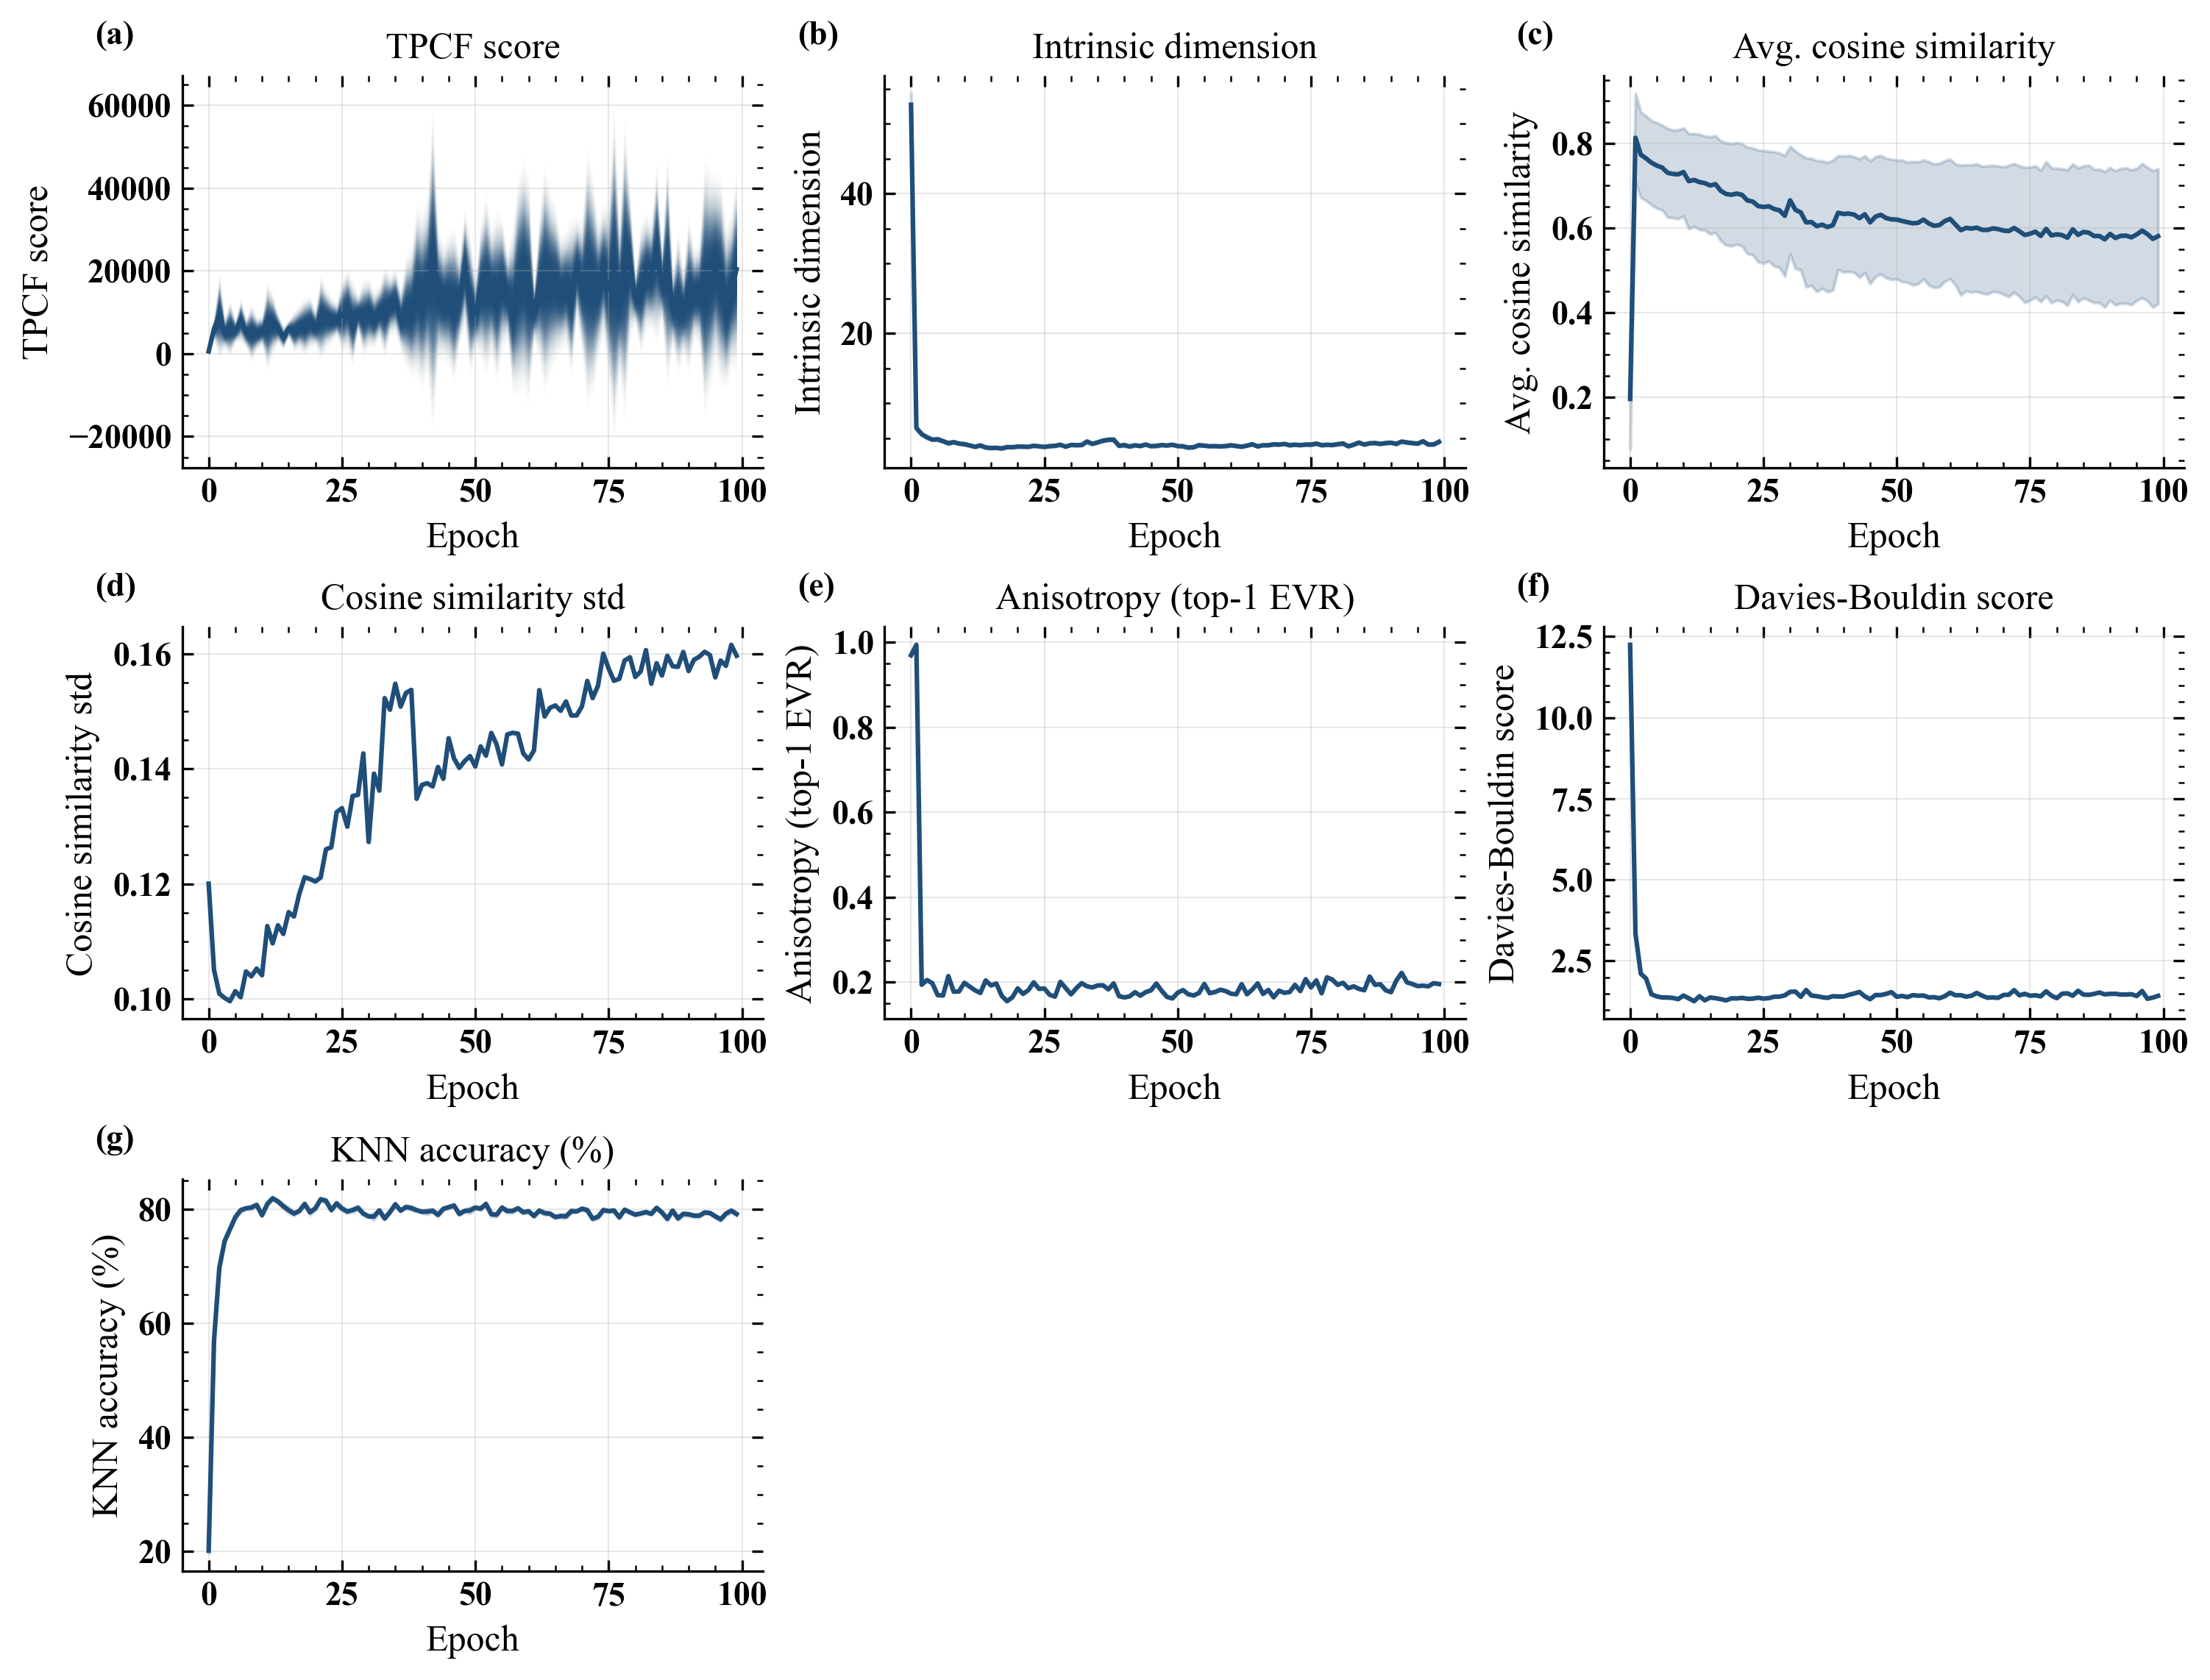

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import string

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "lines.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
})

ACCENT = "#1f4e79"

metrics = [
    ("tpcf_score", "TPCF score", "tpcf_std"),
    ("id_mean", "Intrinsic dimension", "id_std"),
    ("avg_cosine_similarity", "Avg. cosine similarity", "cosine_similarity_std"),
    ("cosine_similarity_std", "Cosine similarity std", None),
    ("anisotropy", "Anisotropy (top-1 EVR)", None),
    ("davies_bouldin", "Davies-Bouldin score", None),
    ("knn_accuracy", "KNN accuracy (%)", "knn_accuracy_std"),
]


def plot_gradient_band(ax, x, y, y_err, color=ACCENT, n_layers=40, max_sigma=3.0):
    """Shade the uncertainty band with an alpha gradient that fades away from the mean."""
    x = np.asarray(x)
    y = np.asarray(y)
    y_err = np.asarray(y_err)
    sigmas = np.linspace(max_sigma / n_layers, max_sigma, n_layers)
    for sigma in sigmas[::-1]:
        alpha = 0.35 * np.exp(-0.5 * sigma ** 2)
        ax.fill_between(x, y - sigma * y_err, y + sigma * y_err, color=color, alpha=alpha, linewidth=0)


n_cols = 3
n_rows = -(-len(metrics) // n_cols)  # ceil division

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(3.3 * n_cols, 2.5 * n_rows), squeeze=False, constrained_layout=True
)
axes = axes.flatten()

for panel_label, ax, (col, title, err_col) in zip(string.ascii_lowercase, axes, metrics):
    ax.plot(results["epoch"], results[col], color=ACCENT)
    if col == "tpcf_score":
        plot_gradient_band(ax, results["epoch"], results[col], results[err_col])
    elif err_col is not None:
        ax.fill_between(
            results["epoch"],
            results[col] - results[err_col],
            results[col] + results[err_col],
            color=ACCENT,
            alpha=0.2,
        )
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.text(-0.15, 1.08, f"({panel_label})", transform=ax.transAxes, fontsize=11, fontweight="bold")

# hide any unused axes in the grid
for ax in axes[len(metrics):]:
    ax.axis("off")

fig.savefig("Test_metrics_grid.pdf", bbox_inches="tight")
fig.savefig("Test_metrics_grid.png", bbox_inches="tight")
plt.show()
